In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from river.decomposition import OnlineDMDwC
from river.feature_extraction import PolynomialExtender
from river.preprocessing import Hankelizer
from tqdm import tqdm

sys.path.append("../")

from functions.chdsubid import (
    SubIDChangeDetector,
    get_default_rank,
    get_default_timedelays,
)
from functions.plot import plot_chd
from functions.preprocessing import hankel, polynomial_extension
from functions.rolling import Rolling

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
# Read data
hm = 1
train_data = pd.read_pickle("data/nonlinear-delay-control/train_sim.pkl")
X = pd.DataFrame(train_data["X"][:12000])
U = pd.DataFrame(train_data["U"][:12000])
Y = np.zeros(X.shape[0])

# Introduce gaussian noise
np.random.seed(42)
noise = 0.1
X += np.random.normal(0, noise, X.shape)

# Introduce step reduction in response amplitude
X[3998:4998] += 1.0
Y[3998:4998] = 1

# Introduce step reduction in response amplitude
X[7598:8598] *= 2.0
Y[7598:8598] = 1

# Introduce gradual reduction in responsiveness from 1.0 to 0.25
X[9798:12000] *= np.linspace(1.0, 2.0, X[9798:12000].shape[0])[:, None]
Y[9798:12000] = 1

# X[14998:] += np.linspace(0.0, 1.0, X[14998:].shape[0])[:, None]
# Y[14998:] = 1

In [4]:
n, m = X.shape
n_inputs_in_ = U.shape[1]

window_size: int = 2000
# Base size
ref_size = 200
test_size = 200

m_ext = 2
X_ = polynomial_extension(X, m_ext)
# If window_size is not very large, then take half
hm, hm_step = get_default_timedelays(200)
hl, hl_step = get_default_timedelays(30, 30 // U.shape[1])
# Optimal low-rank representation of signal with unknown noise variance
p = get_default_rank(hankel(X_[:window_size], hm, hm_step), noise)
print(f"Optimal rank for states is: {p}")
q = get_default_rank(hankel(U[:window_size], hl, hl_step), 0)
q = 2
print(f"Optimal rank for inputs is: {q}")

Optimal rank for states is: 24
Optimal rank for inputs is: 2


Snapshots processed: 100%|██████████| 12000/12000 [20:01<00:00,  9.99it/s] 


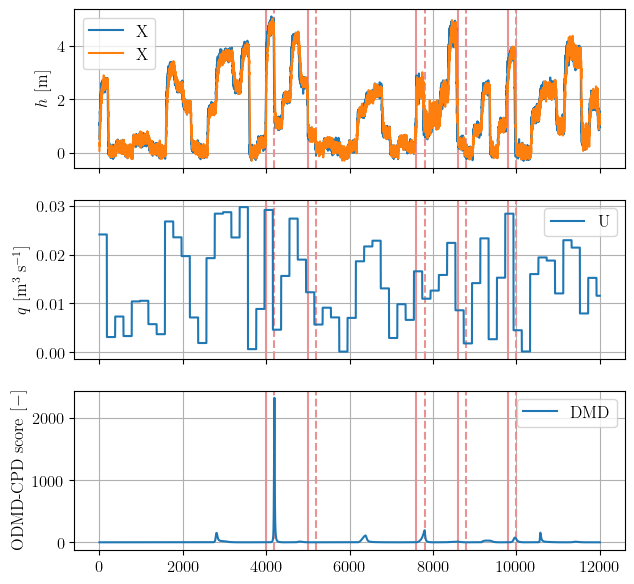

In [5]:
# [donotremove]
# TODO: enable hankelization of us on the fly
U_ = pd.DataFrame(hankel(U, hl, hl_step))

# Initialize Hankelizer
hankelizer = Hankelizer(hm)

# Initialize Transformer
init_size = window_size
odmd = Rolling(
    OnlineDMDwC(
        p=p,
        q=q,
        initialize=init_size - 1,
        w=1.0,
        exponential_weighting=False,
        eig_rtol=None,
    ),
    init_size,
)

# Initialize Change-Point Detector
subid_dmd = SubIDChangeDetector(
    odmd,
    ref_size=ref_size,
    test_size=test_size,
    grace_period=init_size,
    start_soon=True,
    # learn_after_grace=False,
)

# Build pipeline
pipeline_dmd = PolynomialExtender(m_ext) | hankelizer | subid_dmd

# Prepare arrays for storing results
scores_dmd = np.zeros(n, dtype=float)
scores_dmd_diff = np.zeros(n, dtype=complex)
dist = np.zeros((n, 2), dtype=complex)
modes = np.empty((n, hm * m, p), dtype=complex)
X_h = []
X_tilde = []

# Run pipeline
for i, (x, u) in tqdm(
    enumerate(
        zip(
            X.to_dict(orient="records"),
            U_.to_dict(orient="records"),
        )
    ),
    total=len(X),
    mininterval=1.0,
    desc="Snapshots processed",
):
    X_h.append(hankelizer.transform_one(x))
    try:
        X_tilde.append(odmd.transform_one(X_h[-1]))
    except AttributeError:
        X_tilde.append(dict(*[zip(range(p), np.zeros(p) * np.nan)]))
    scores_dmd[i] = pipeline_dmd.score_one(x)
    dist[i, :] = subid_dmd.distances
    scores_dmd_diff[i] = dist[i, 1] - dist[i, 0]

    pipeline_dmd.learn_one(x, **{"u": u})
    x_ = x.copy()
    x_.update({-1: u.copy().popitem()[1]})

# Plot results
fig, axs = plot_chd(
    {
        "$h~$[m]": X,
        "$q~\\mathrm{[m^3~s^{-1}]}$": U,
        "ODMD-CPD score [$-$]": scores_dmd.real,
    },
    np.where(np.abs(np.diff(Y, axis=0, prepend=0)) == 1)[0],
    # np.where(Y == 1)[0],
    labels=["X", "U", "DMD", "SVD"],
    grace_period=test_size,
)
fig_name = (
    f"results/.nonlin/nonlin-chd_p{p}_q{q}-l{init_size}_b{ref_size}_t{test_size}"
    f"{f'roll_{odmd.window_size}' if isinstance(odmd, Rolling) else 'noroll'}-"
    f"dmd_w{odmd.w}-hx{hm}-hl{hl}.pdf"
)
os.makedirs(os.path.dirname(fig_name), exist_ok=True)
fig.savefig(fig_name)

In [25]:
idx_start = 3198
idx_end = 4098

In [37]:
plt.rcParams

RcParams({'_internal.classic_mode': False,
          'agg.path.chunksize': 0,
          'animation.bitrate': -1,
          'animation.codec': 'h264',
          'animation.convert_args': ['-layers', 'OptimizePlus'],
          'animation.convert_path': 'convert',
          'animation.embed_limit': 20.0,
          'animation.ffmpeg_args': [],
          'animation.ffmpeg_path': 'ffmpeg',
          'animation.frame_format': 'png',
          'animation.html': 'none',
          'animation.writer': 'ffmpeg',
          'axes.autolimit_mode': 'data',
          'axes.axisbelow': 'line',
          'axes.edgecolor': 'black',
          'axes.facecolor': 'white',
          'axes.formatter.limits': [-5, 6],
          'axes.formatter.min_exponent': 0,
          'axes.formatter.offset_threshold': 4,
          'axes.formatter.use_locale': False,
          'axes.formatter.use_mathtext': False,
          'axes.formatter.useoffset': True,
          'axes.grid': True,
          'axes.grid.axis': 'both',
    

In [50]:
plt.rcParams.update(
    {
        "figure.figsize": [3, 3],
        "xtick.bottom": False,
        "ytick.left": False,
    }
)

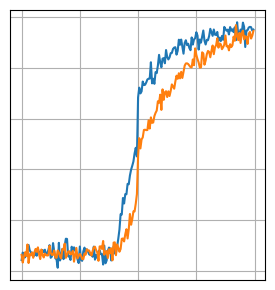

In [53]:
plt.plot(X.values[idx_end - test_size : idx_end])

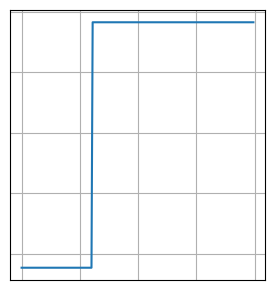

In [54]:
plt.plot(U.values[idx_end - test_size : idx_end])

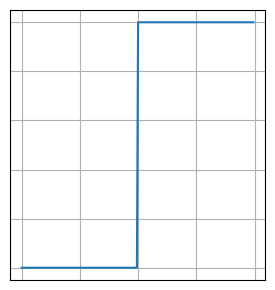

In [55]:
plt.plot(Y[idx_end - test_size : idx_end])

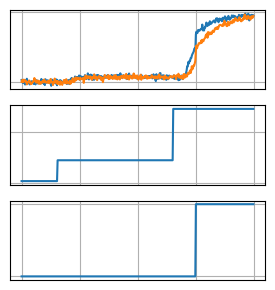

In [56]:
fig, axs = plt.subplots(3, 1, sharex=True)
axs[0].plot(X.values[idx_end - test_size - ref_size : idx_end])
axs[1].plot(U.values[idx_end - test_size - ref_size : idx_end])
axs[2].plot(Y[idx_end - test_size - ref_size : idx_end])

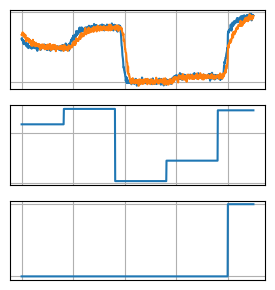

In [57]:
fig, axs = plt.subplots(3, 1, sharex=True)
axs[0].plot(X.values[idx_start:idx_end])
axs[1].plot(U.values[idx_start:idx_end])
axs[2].plot(Y[idx_start:idx_end])

In [58]:
X_h = pd.DataFrame(X_h)
X_tilde = pd.DataFrame(X_tilde)

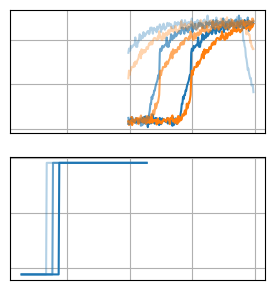

In [59]:
X_h_ = X_h.iloc[idx_end - test_size + hm : idx_end + hm, :300]
fig, axs = plt.subplots(2, 1, sharex=True)
for i in range(0, len(X_h_.columns), 2 * 50):
    axs[0].plot(
        X_h_.iloc[:, i], alpha=1 - (i / len(X_h_.columns)), color="tab:blue"
    )
    axs[0].plot(
        X_h_.iloc[:, i + 1],
        alpha=1 - (i / len(X_h_.columns)),
        color="tab:orange",
    )
    axs[0].set_prop_cycle(None)
U_h_ = U_.iloc[idx_end - test_size + hl : idx_end + hl]
for i in range(0, len(U_h_.columns), 2 * 5):
    axs[1].plot(
        U_h_.iloc[:, i],
        color="tab:blue",
        alpha=1 - (i / len(U_h_.columns)),
    )
    axs[1].set_prop_cycle(None)

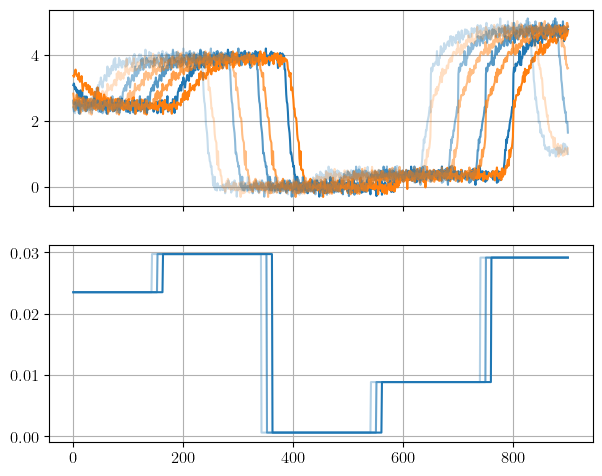

In [829]:
X_h_ = X_h.values[idx_start + hm : idx_end + hm, : m * hm]
fig, axs = plt.subplots(2, 1, sharex=True)
for i in range(0, X_h_.shape[1], 2 * 50):
    axs[0].plot(X_h_[:, i], alpha=1 - (i / X_h_.shape[1]), color="tab:blue")
    axs[0].plot(
        X_h_[:, i + 1],
        alpha=1 - (i / X_h_.shape[1]),
        color="tab:orange",
    )
    axs[0].set_prop_cycle(None)
U_h_ = U_.values[idx_start + hl : idx_end + hl]
for i in range(0, U_h_.shape[1], 2 * 5):
    axs[1].plot(
        U_h_[:, i],
        color="tab:blue",
        alpha=1 - (i / U_h_.shape[1]),
    )
    axs[1].set_prop_cycle(None)

<Axes: >

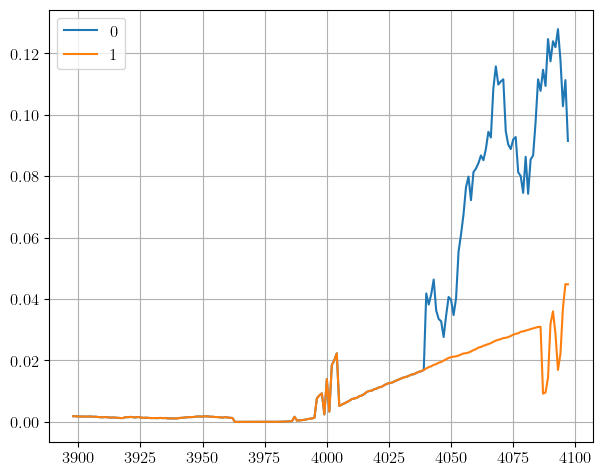

In [831]:
pd.DataFrame(X_tilde).iloc[idx_end - test_size : idx_end, :2].abs().plot()

<Axes: >

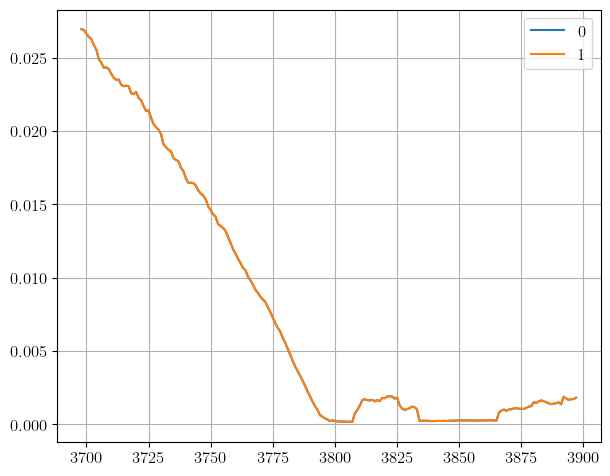

In [839]:
pd.DataFrame(X_tilde).iloc[
    idx_end - test_size - ref_size : idx_end - test_size, :2
].abs().plot()

/Users/mw/pyprojects/odmd-subid-cpd/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/mw/pyprojects/odmd-subid-cpd/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


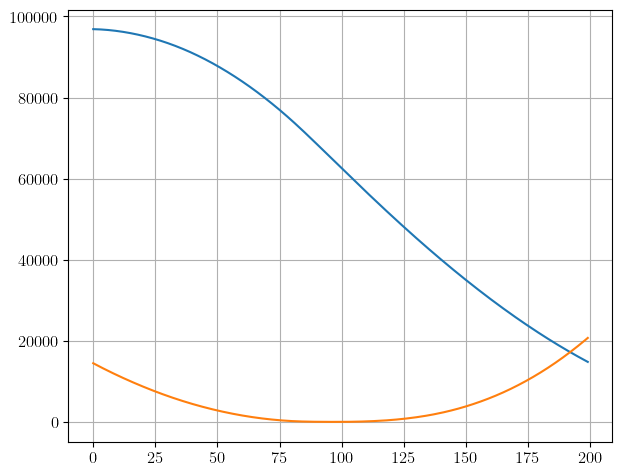

In [833]:
plt.plot(dist[idx_end - test_size : idx_end])

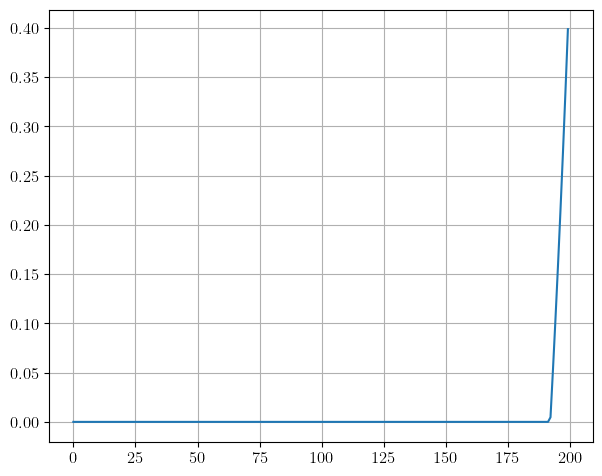

In [834]:
plt.plot(scores_dmd[idx_end - test_size : idx_end])

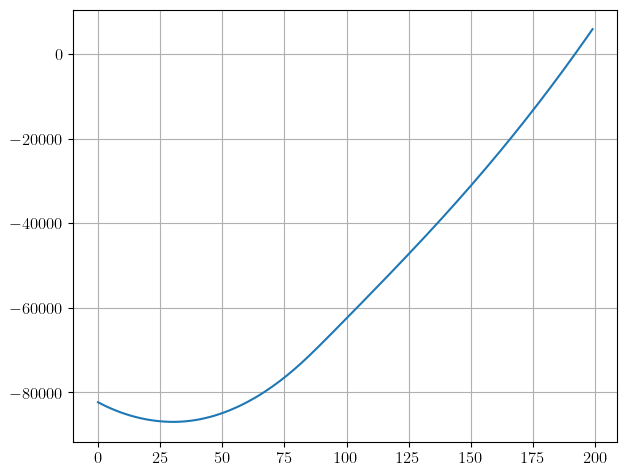

In [835]:
plt.plot(scores_dmd_diff.real[idx_end - test_size : idx_end])

/Users/mw/pyprojects/odmd-subid-cpd/.venv/lib/python3.12/site-packages/pydmd/plotter.py:752: UserWarning: No time information available. Using dt = 1 and t0 = 0.
  except AttributeError:


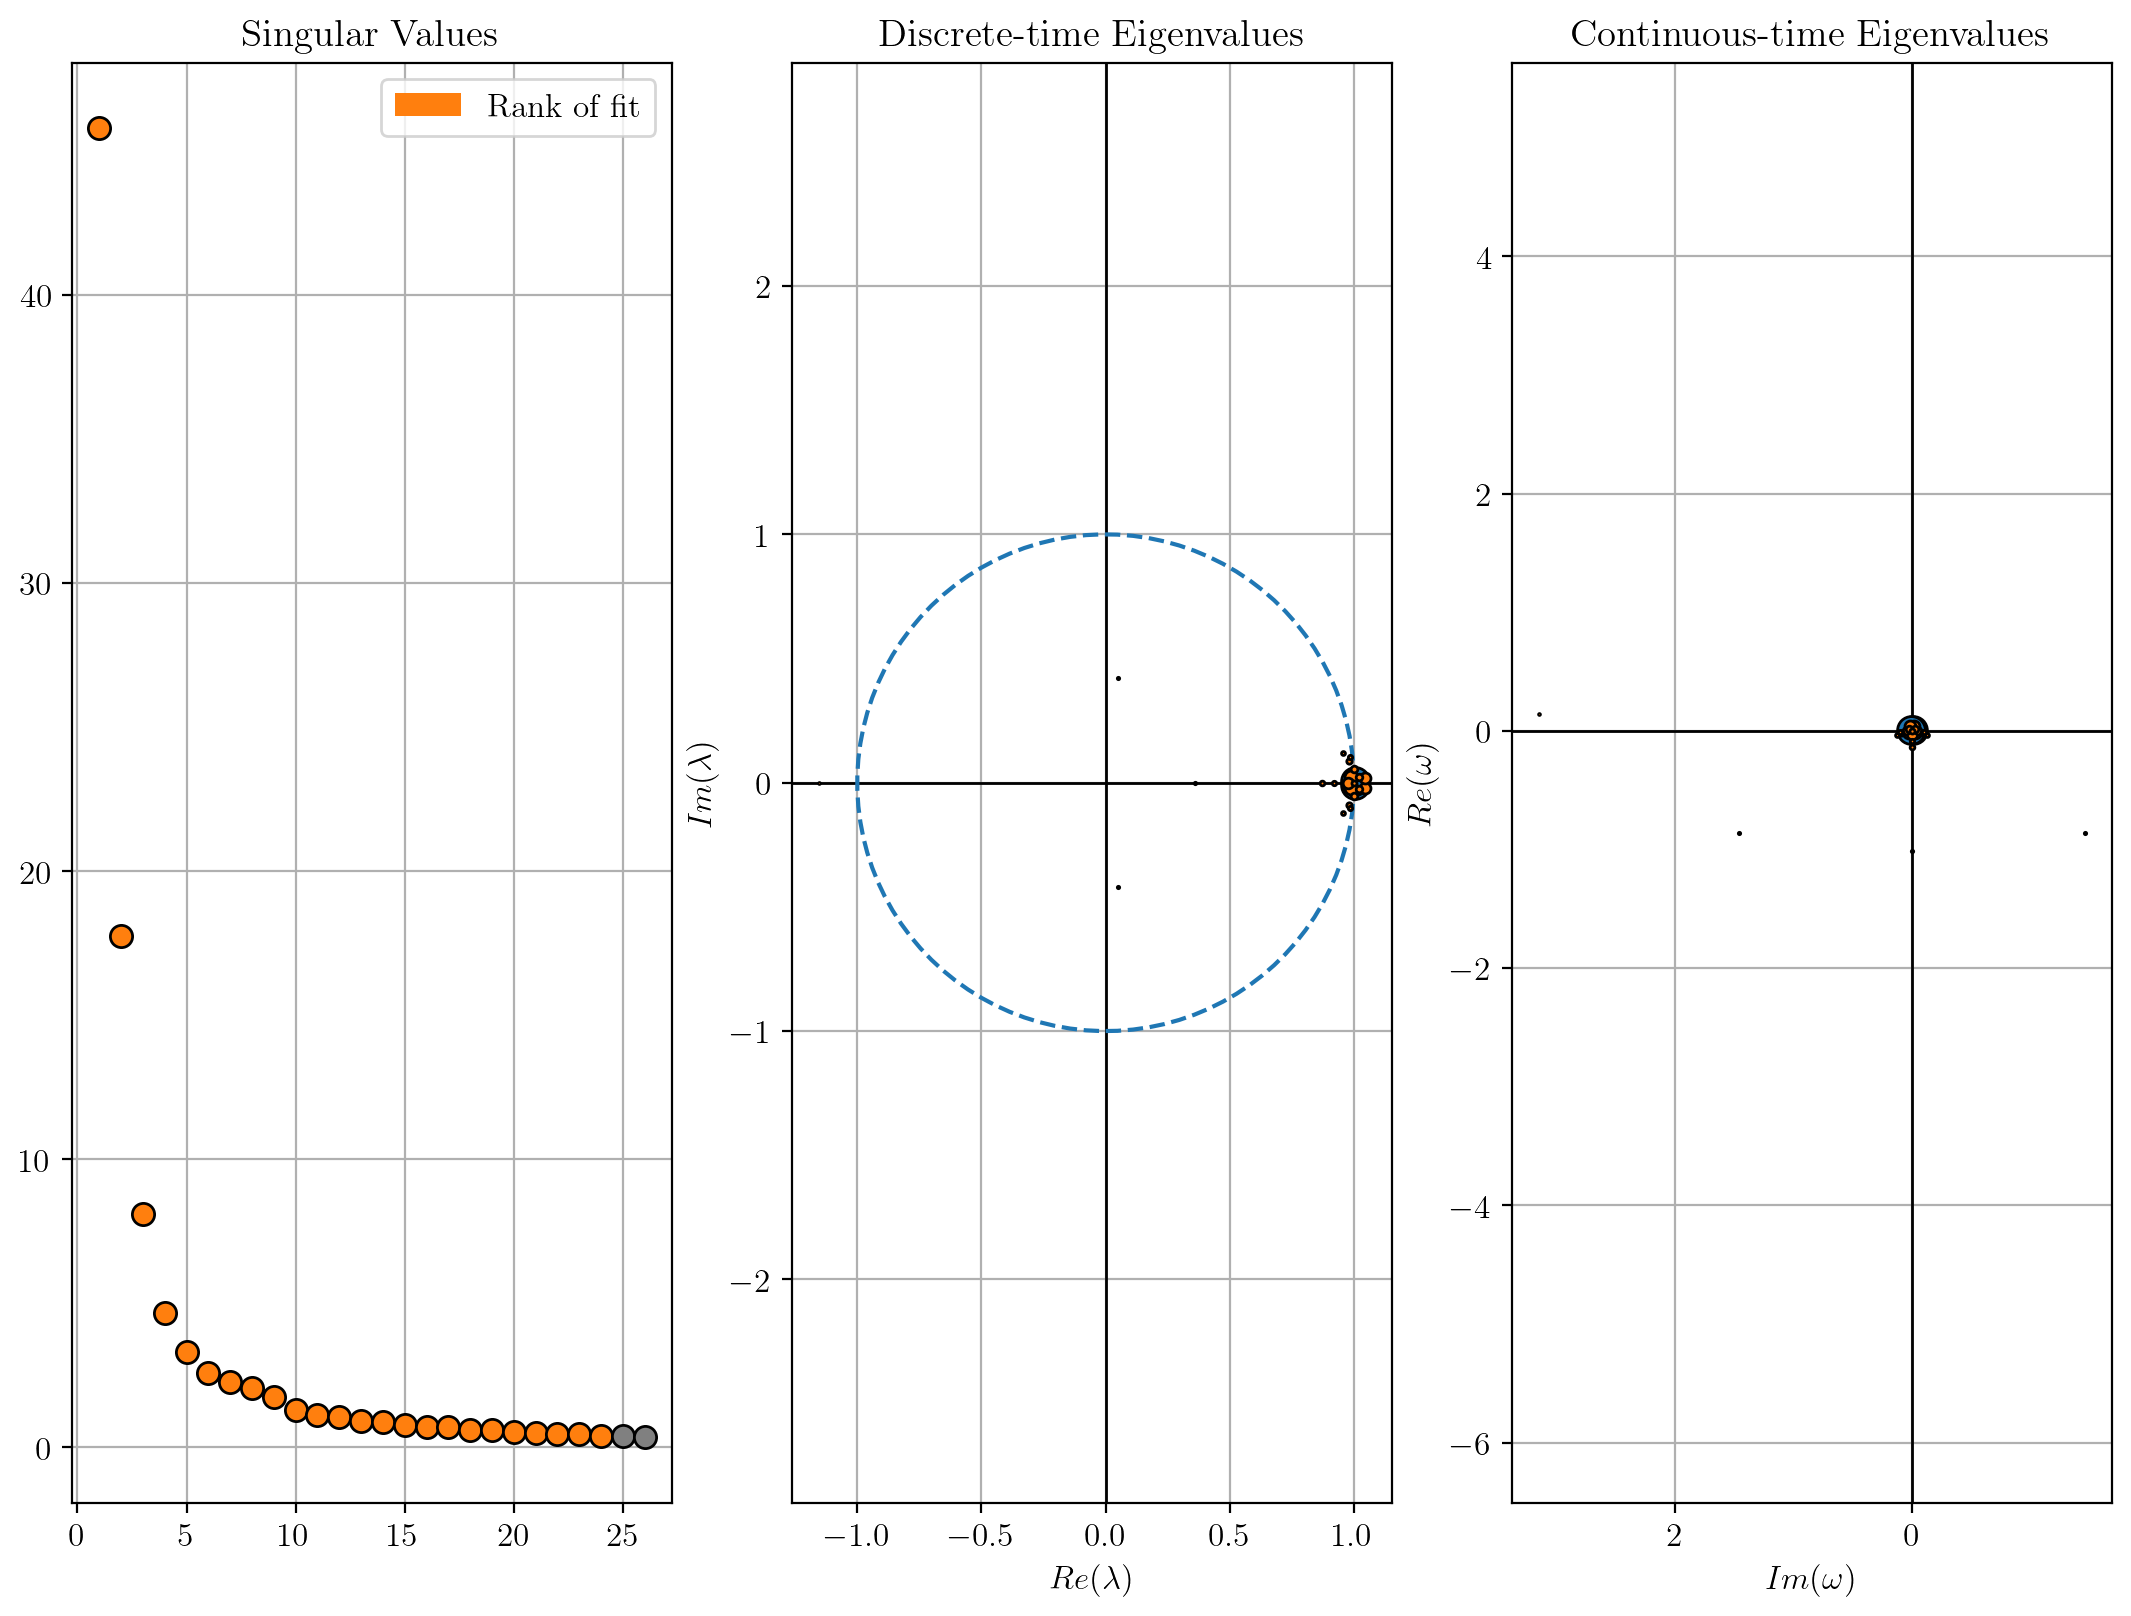

In [836]:
from pydmd.plotter import plot_summary

odmd.snapshots = odmd._Y[:, :, np.newaxis]
odmd.amplitudes = odmd.xi
odmd.eigs = odmd.eig[0]

plot_summary(
    odmd,  # <-- Fitted PyDMD model. Can be DMD, BOPDMD, etc.
    index_modes=(0, 1, 2),
    snapshots_shape=(1000, 24),
    order="F",
    mode_cmap="viridis",
    dynamics_color="k",
    flip_continuous_axes=True,
    max_sval_plot=30,
)